<a href="https://colab.research.google.com/github/sirichandanakatharashala16-cell/ML-Project/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predictive Modeling of Stock Prices with Machine Learning Techniques.**

In [ ]:
!pip install librosa

**STEP 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

**STEP 2: Upload Dataset**

In [ ]:
df = pd.read_csv("/content/stockprices.csv")
print(df.head())

                  date symbol        open       close         low        high  \
0  2016-01-05 00:00:00   WLTW  123.430000  125.839996  122.309998  126.250000   
1  2016-01-06 00:00:00   WLTW  125.239998  119.980003  119.940002  125.540001   
2  2016-01-07 00:00:00   WLTW  116.379997  114.949997  114.930000  119.739998   
3  2016-01-08 00:00:00   WLTW  115.480003  116.620003  113.500000  117.440002   
4  2016-01-11 00:00:00   WLTW  117.010002  114.970001  114.089996  117.330002   

      volume  
0  2163600.0  
1  2386400.0  
2  2489500.0  
3  2006300.0  
4  1408600.0  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
None


**STEP 3: Data Preprocessing**

In [ ]:
# Remove missing values
df.dropna(inplace=True)

# Convert date
df['date'] = pd.to_datetime(df['date'], format='mixed')

# Sort data
df = df.sort_values('date')

**STEP 4: Data Visualization**

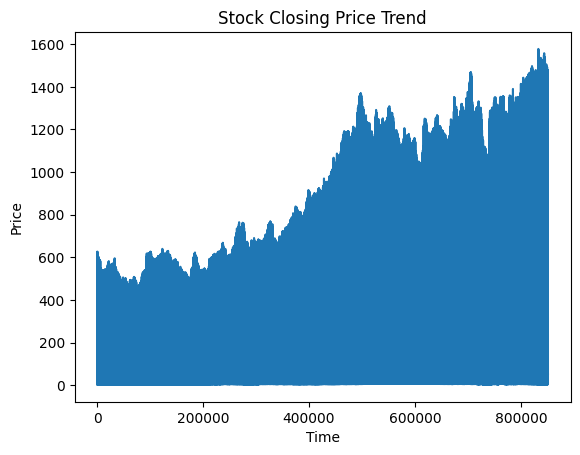

In [ ]:
plt.figure()
plt.plot(df['close'])
plt.title("Stock Closing Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

**STEP 5: Features**

In [ ]:
X = df[['open', 'high', 'low', 'volume']]
y = df['close']

# Classification target
y_clf = (y.shift(-1) > y).astype(int)

X = X[:-1]
y = y[:-1]
y_clf = y_clf[:-1]

**STEP 6: Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

**STEP 7: Linear Regression**

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mse = mean_squared_error(y_test, pred_lr)
r2 = r2_score(y_test, pred_lr)

print("Linear Regression MSE:", mse)
print("R2 Score:", r2)

Linear Regression MSE: 0.4096742833069054
R2 Score: 0.9999413133600344


**STEP 8: Ridge Regression**

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, pred_ridge)
r2_ridge = r2_score(y_test, pred_ridge)

print("Ridge Regression MSE:", mse_ridge)
print("Ridge Regression R2 Score:", r2_ridge)

Ridge Regression MSE: 0.40967429101432407
Ridge Regression R2 Score: 0.9999413133589303


**STEP 9: Logistic Regression**

In [ ]:
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train_clf)

pred_log = log.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, pred_log))
print("F1 Score:", f1_score(y_test_clf, pred_log))
print("Recall:", recall_score(y_test_clf, pred_log))

Accuracy: 0.626702613169812
F1 Score: 0.48084039242274484
Recall: 0.3429463651087729


**STEP 10: Confusion Matrix**

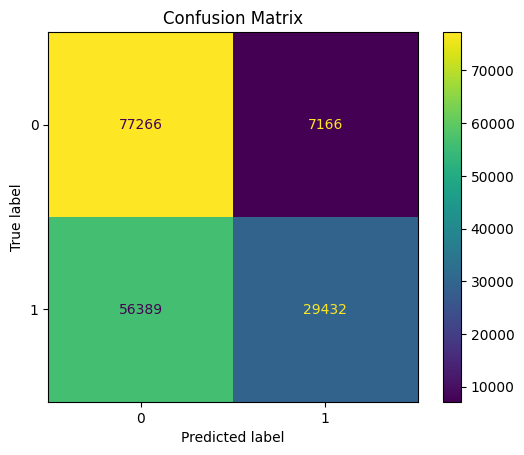

In [ ]:
cm = confusion_matrix(y_test_clf, pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

**STEP 11: ROC Curve**

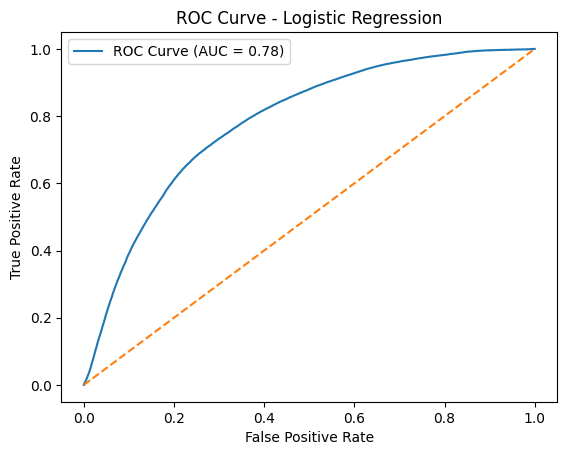

In [ ]:
y_prob = log.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

**STEP 12: Prediction Graph**

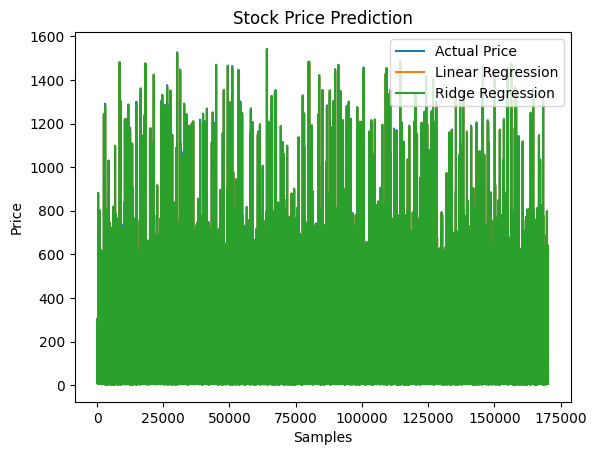

In [ ]:
plt.figure()

plt.plot(y_test.values, label="Actual Price")
plt.plot(pred_lr, label="Linear Regression")
plt.plot(pred_ridge, label="Ridge Regression")

plt.legend()
plt.title("Stock Price Prediction")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.show()